# NFL Third Down Conversion Prediction

## By Brady Tokarski and Luke Paul

## Step 1: Goal and Dataset
The goal of this project is to predict whether an NFL offense will convert a third-down play into a first down using information about the game situation and play.

In [1]:
!pip install nflreadpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nflreadpy as nfl

In [3]:
# Load NFL data from 2025 season

pbp = nfl.load_pbp([2025])

pbp = pbp.to_pandas()

pbp.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.0,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,None,None,None,...,0.0,0.0,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.0,0.0,-0.352700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63.0,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.0,0.0,-0.190052,NaN,NaN,NaN,NaN,NaN,0.511128,-51.112807
3,85.0,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1.0,0.0,1.317340,0.939998,4.750889,3.0,0.666726,0.43911,0.668940,33.105969
4,115.0,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0.0,0.0,-1.694360,NaN,NaN,NaN,NaN,NaN,0.492038,50.796208


In [4]:
# See list of all column names

pbp.columns.tolist()

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

In [5]:
# Filter to Third Downs

third_downs = pbp[pbp["down"] == 3].copy()
third_downs.shape

(7934, 372)

In [6]:
# Keep Relevant Columns

columns = [
    "game_id",
    "season",
    "week",
    "posteam",
    "defteam",
    "home_team",
    "away_team",
    "qtr",
    "game_seconds_remaining",
    "yardline_100",
    "ydstogo",
    "score_differential",
    "shotgun",
    "no_huddle",
    "play_type",
    "first_down"
]

third_downs = third_downs[columns].copy()

In [7]:
# Target Variable

third_downs["converted"] = third_downs["first_down"]
third_downs["converted"].value_counts()
third_downs["converted"].value_counts(normalize=True)

converted
0.0    0.605253
1.0    0.394747
Name: proportion, dtype: float64

In [8]:
# Remove missing values

third_downs = third_downs.dropna(subset=["converted"])
third_downs.shape

(7919, 17)

In [9]:
# Number of play types

third_downs["play_type"].value_counts(dropna=False)

play_type
pass          5254
run           1906
no_play        652
qb_kneel        61
field_goal      37
qb_spike         9
Name: count, dtype: int64

In [10]:
# Grab only pass and run play types for our testing, we do not want plays that can not result in a conversion

third_downs = third_downs[
    third_downs["play_type"].isin(["run", "pass"])
].copy()

third_downs.shape

(7160, 17)

In [11]:
# Check missing values

third_downs.isnull().sum()

game_id                   0
season                    0
week                      0
posteam                   0
defteam                   0
home_team                 0
away_team                 0
qtr                       0
game_seconds_remaining    0
yardline_100              0
ydstogo                   0
score_differential        0
shotgun                   0
no_huddle                 0
play_type                 0
first_down                0
converted                 0
dtype: int64

# Step 2: Perform a Brief Exploratory Data Analysis
## Descriptive Statistics

In [12]:
# Yards to go

third_downs["ydstogo"].describe()

count    7160.000000
mean        6.881564
std         4.962685
min         1.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        36.000000
Name: ydstogo, dtype: float64

In [13]:
# Field Position

third_downs["yardline_100"].describe()

count    7160.000000
mean       47.573324
std        23.845048
min         1.000000
25%        29.000000
50%        50.000000
75%        66.000000
max        99.000000
Name: yardline_100, dtype: float64

In [14]:
# Conversion Rate

third_downs["converted"].mean()

np.float64(0.4020949720670391)

## Histogram of the Distribution of "Yards to Go" on Third Down:

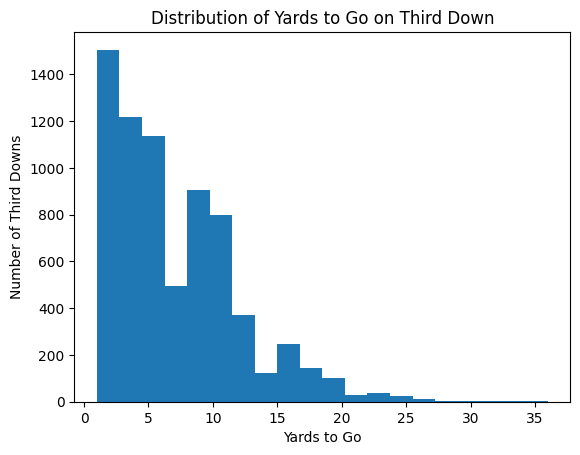

In [15]:
plt.hist(third_downs["ydstogo"], bins=20)

plt.xlabel("Yards to Go")
plt.ylabel("Number of Third Downs")
plt.title("Distribution of Yards to Go on Third Down")

plt.show()

## Third Down Conversion Rate By Yards to Go:

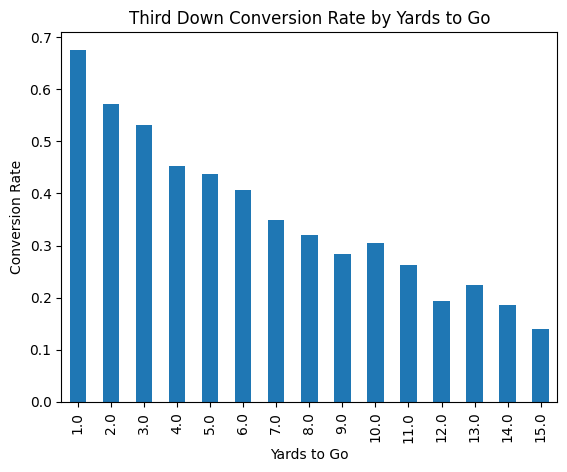

In [16]:
conversion_by_distance = (
    third_downs
    .groupby("ydstogo")["converted"]
    .mean()
)

conversion_by_distance.loc[1:15].plot(kind="bar")

plt.xlabel("Yards to Go")
plt.ylabel("Conversion Rate")
plt.title("Third Down Conversion Rate by Yards to Go")

plt.show()

# Step 3: Train/Test Split

In [17]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "qtr",
    "game_seconds_remaining",
    "yardline_100",
    "ydstogo",
    "score_differential",
    "shotgun",
    "no_huddle",
    "play_type"
]

X = third_downs[feature_cols]
y = third_downs["converted"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())


(5728, 8) (1432, 8)
0.4020600558659218 0.4022346368715084


# Step 4: Feature Engineering

The categorical variable `play_type` will be dummy encoded during
preprocessing using OneHotEncoder. This allows the encoding to be learned
using only the training data and applied consistently to the testing data.

In [18]:
# Check the predictor variables before preprocessing
X_train.head()

,qtr,game_seconds_remaining,yardline_100,ydstogo,score_differential,shotgun,no_huddle,play_type
46059,3.0,1724.0,82.0,4.0,-7.0,1.0,0.0,pass
47982,3.0,1545.0,87.0,1.0,0.0,0.0,0.0,run
25274,2.0,1978.0,61.0,11.0,0.0,1.0,0.0,run
47566,2.0,1915.0,63.0,3.0,0.0,1.0,0.0,pass
13340,1.0,3126.0,76.0,6.0,7.0,1.0,0.0,pass


# Step 5: Rescaling the data

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    "game_seconds_remaining",
    "yardline_100",
    "ydstogo",
    "score_differential"
]

categorical_features = [
    "qtr",
    "shotgun",
    "no_huddle",
    "play_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Step 6: Train and Tune Candidate Models

## Model Type 1: Logistic Regression

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# Create Logistic Regression Model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit Model
logistic_model.fit(X_train, y_train);

# Cross-Validation predicted probabilities
y_cv_prob = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

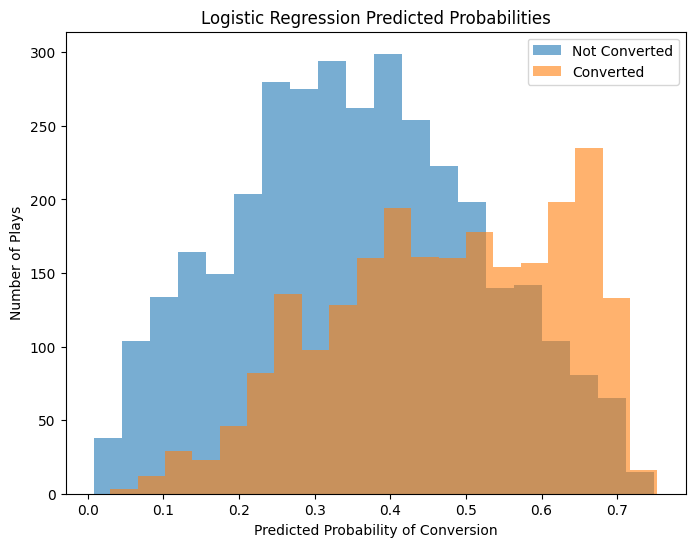

In [21]:
plt.figure(figsize=(8, 6))

plt.hist(
    y_cv_prob[y_train.to_numpy() == 0],
    bins=20,
    alpha=0.6,
    label="Not Converted"
)

plt.hist(
    y_cv_prob[y_train.to_numpy() == 1],
    bins=20,
    alpha=0.6,
    label="Converted"
)

plt.xlabel("Predicted Probability of Conversion")
plt.ylabel("Number of Plays")
plt.title("Logistic Regression Predicted Probabilities")
plt.legend()

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score

cv_auc = roc_auc_score(y_train, y_cv_prob)

print("Logistic Regression Model Performance:")
print("--------------------------------------")
print("Cross-Validation ROC-AUC:", round(cv_auc, 4))

Logistic Regression Model Performance:
--------------------------------------
Cross-Validation ROC-AUC: 0.6978


In [46]:
from sklearn.model_selection import GridSearchCV

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    logistic_model,
    logistic_params,
    cv=5,
    scoring="roc_auc"
)

logistic_grid.fit(X_train, y_train);

The logistic regression model generally assigned higher predicted conversion probabilities to third downs that were actually converted and lower probabilities to those that were not converted. However, the considerable overlap between the two distributions shows that the model has only moderate ability to distinguish between successful and unsuccessful third-down attempts.

## Model Type 2: Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=10
    ))
])

rf_model.fit(X_train, y_train);

rf_cv_prob = cross_val_predict(
    rf_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

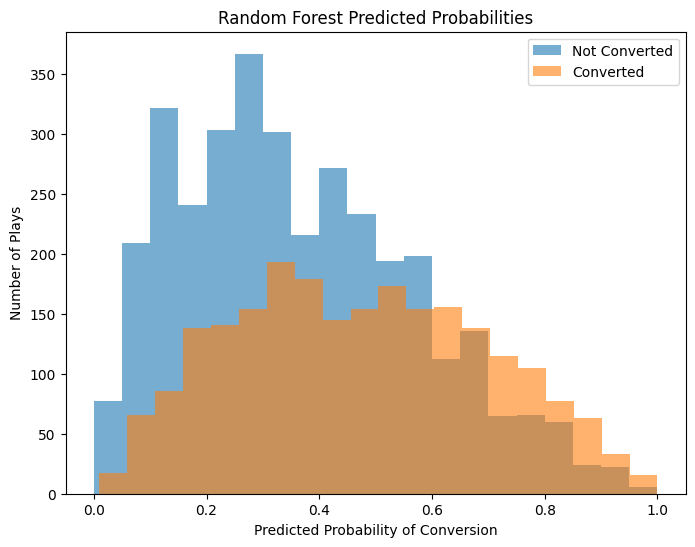

In [37]:
plt.figure(figsize=(8, 6))

plt.hist(
    rf_cv_prob[y_train.to_numpy() == 0],
    bins=20,
    alpha=0.6,
    label="Not Converted"
)

plt.hist(
    rf_cv_prob[y_train.to_numpy() == 1],
    bins=20,
    alpha=0.6,
    label="Converted"
)

plt.xlabel("Predicted Probability of Conversion")
plt.ylabel("Number of Plays")
plt.title("Random Forest Predicted Probabilities")
plt.legend()

plt.show()

In [38]:
rf_cv_auc = roc_auc_score(y_train, rf_cv_prob)

print("Random Forest Model Performance:")
print("--------------------------------")
print("Cross-Validation ROC-AUC:", round(rf_cv_auc, 4))

Random Forest Model Performance:
--------------------------------
Cross-Validation ROC-AUC: 0.6422


In [39]:
print("Logistic Regression CV ROC-AUC:", round(cv_auc, 4))
print("Random Forest CV ROC-AUC:", round(rf_cv_auc, 4))

Logistic Regression CV ROC-AUC: 0.6978
Random Forest CV ROC-AUC: 0.6422


In [40]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Random Forest CV ROC-AUC:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best Random Forest CV ROC-AUC:
0.6986133486528742


In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "CV ROC-AUC": [
        cv_auc,
        logistic_grid.best_score_,
        rf_grid.best_score_
    ]
})

comparison

,Model,CV ROC-AUC
0,Baseline Logistic Regression,0.697828
1,Tuned Logistic Regression,0.698606
2,Tuned Random Forest,0.698613


**Model Observations**: The baseline logistic regression model achieved a cross-validation ROC-AUC of 0.6978, while tuning the regularization parameter produced a very small improvement to 0.6986. The baseline Random Forest performed worse with a ROC-AUC of 0.6422, but after hyperparameter tuning its ROC-AUC improved substantially to 0.6986. The tuned Random Forest produced the highest cross-validation ROC-AUC, although its performance was nearly identical to the tuned logistic regression model. Based on cross-validation ROC-AUC, we selected the tuned Random Forest as our final model for evaluation on the testing dataset.[link text](https://)

# Step 7: Model Performance

In [42]:
best_model = rf_grid.best_estimator_

y_test_pred = best_model.predict(X_test)

y_test_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Final Random Forest Test Performance:")
print("-------------------------------------")
print("Accuracy:", round(test_accuracy, 4))
print("ROC-AUC:", round(test_auc, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Random Forest Test Performance:
-------------------------------------
Accuracy: 0.6571
ROC-AUC: 0.6997
Sensitivity: 0.3038
Specificity: 0.8949

Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.89      0.76       856
         1.0       0.66      0.30      0.42       576

    accuracy                           0.66      1432
   macro avg       0.66      0.60      0.59      1432
weighted avg       0.66      0.66      0.62      1432



**Test Performance Observation**: The final Random Forest model achieved an accuracy of 65.7% and a ROC-AUC of approximately 0.70. The model had high specificity (89.5%), meaning it was strong at correctly identifying failed third downs, but its sensitivity was much lower (30.4%), showing that it missed many actual conversions.

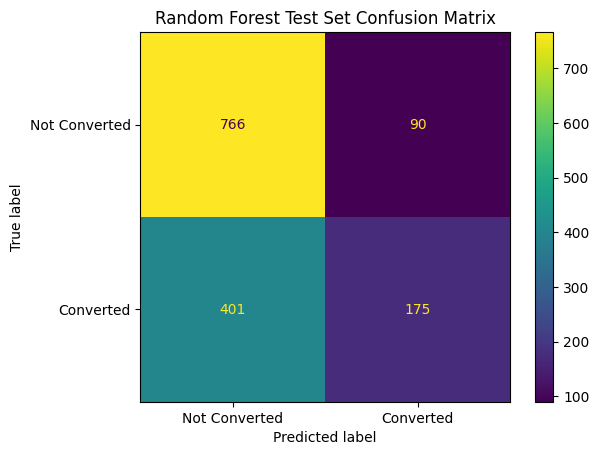

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Not Converted", "Converted"]
)

plt.title("Random Forest Test Set Confusion Matrix")
plt.show()

**Confusion Matrix Observation**: The model correctly predicted 766 failed conversions and 175 successful conversions. However, it incorrectly classified 401 actual conversions as failures, which explains the model's relatively low sensitivity.

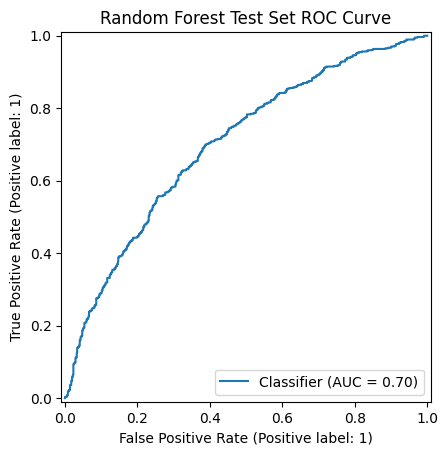

In [44]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("Random Forest Test Set ROC Curve")
plt.show()

**Overall Model Performance**: The ROC curve and AUC of about 0.70 indicate that the Random Forest model has moderate ability to distinguish between converted and non-converted third downs. The model performs much better at predicting failed third downs than successful ones, suggesting that additional predictors or a different classification threshold could potentially improve its ability to identify conversions.

# Step 8: Discussion of Results

Both models showed moderate ability to predict whether a third down would be converted. The baseline logistic regression achieved a cross-validation ROC-AUC of 0.6978, while tuning improved it slightly to 0.6986. The baseline Random Forest initially performed worse, with a ROC-AUC of 0.6422, but after hyperparameter tuning it improved substantially to 0.6986.

The tuned Random Forest produced the highest cross-validation ROC-AUC and was selected as the final model, although its performance was nearly identical to the tuned logistic regression model. On the testing data, the Random Forest achieved an accuracy of 65.7% and a ROC-AUC of approximately 0.70.

The model was much better at identifying failed third downs than successful conversions. Its specificity was 89.5%, while its sensitivity was only 30.4%. This means the model correctly identified most failed third downs but missed many plays that were actually converted.

Overall, the model captured meaningful patterns in third-down success, especially factors such as yards to go and other game-situation variables. However, the relatively low sensitivity suggests that additional predictors, such as team strength, quarterback performance, defensive quality, or formation information, could potentially improve prediction performance.